# MaIA Scoliosis Dataset **v2** — Data Exploration

**Sandbox tier.** Port of `data_exploration.ipynb` to `data/raw/Scoliosis_Dataset_v2/`.

Key differences vs v1:

- Dataset root: `Scoliosis_Dataset_v2/` (Spanish column names in `indice_dataset.csv`).
- Label space already collapsed to T1..L5 (IDs `1..17`). No cervical (C3–C7) or auxiliary entities.
- Metrics come from a single CSV `metricas_cobb_resumen_recalculado.csv` — no per-case JSONs.
- **No CSVL** field in v2 metrics; the `csvl_apex_out_of_range` detector and CSVL plot are dropped.
- Apex / inflection points stored as pixel coordinates directly (not curve indices).
- Audit outputs land in `data/processed/audit_v2/` to avoid clobbering v1.

Three phases, top-to-bottom: Descriptive profile · Inconsistency audit · Clean manifest.

## 0. Setup & Configuration

In [3]:
import hashlib
import json
import os
import random
from collections import Counter
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from PIL import Image


In [4]:
# ── Repo root discovery ──────────────────────────────────────────────────────
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "params.yaml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "params.yaml").exists():
    raise FileNotFoundError("Could not locate repo root (no params.yaml found above CWD).")

# ── Paths (v2 dataset) ───────────────────────────────────────────────────────
DATASET_ROOT     = REPO_ROOT / "data" / "raw" / "Scoliosis_Dataset_v2"
AUDIT_OUT_DIR    = REPO_ROOT / "data" / "processed" / "audit_v2"
INDEX_CSV        = DATASET_ROOT / "indice_dataset.csv"
LABELS_DICT_JSON = DATASET_ROOT / "diccionario_etiquetas_T1_T12_L1_L5.json"
METRICS_CSV      = DATASET_ROOT / "RadiographMetrics" / "metricas_cobb_resumen_recalculado.csv"
CURVES_CSV_DIR   = DATASET_ROOT / "RadiographMetrics" / "curvas_en_pixeles"
OVERLAYS_DIR     = DATASET_ROOT / "RadiographMetrics" / "overlays"
KNOWN_ISSUES_CSV = AUDIT_OUT_DIR / "known_issues.csv"
CLEAN_INDEX_CSV  = AUDIT_OUT_DIR / "clean_index.csv"
AUDIT_OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Seed (single source of truth = params.yaml) ──────────────────────────────
with open(REPO_ROOT / "params.yaml") as f:
    SEED = int(yaml.safe_load(f)["data"]["random_seed"])
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# ── Vertebra ID ranges (v2: IDs 1..17 map to T1..L5 directly) ────────────────
TARGET_VERTEBRA_IDS: tuple[int, ...] = tuple(range(1, 18))   # T1..L5
ALL_VERTEBRA_IDS:    tuple[int, ...] = tuple(range(1, 18))   # v2 label space
TARGET_COVERAGE_FULL = len(TARGET_VERTEBRA_IDS)              # 17

# ── Severity buckets (Cobb degrees) ──────────────────────────────────────────
SEVERITY_BUCKETS: tuple[tuple[str, float, float], ...] = (
    ("normal",    0.0,  10.0),
    ("mild",     10.0,  25.0),
    ("moderate", 25.0,  40.0),
    ("severe",   40.0, 999.0),
)

# ── Audit rule tables (csvl_apex_out_of_range removed — no CSVL in v2) ───────
EXPECTED_ISSUE_CODES: tuple[str, ...] = (
    "missing_pair_binary_mask", "missing_pair_multi_mask", "missing_pair_metrics", "missing_pair_curve",
    "corrupt_file", "index_mismatch", "category_mislabeled", "duplicate_patient_id",
    "dim_mismatch", "resolution_outlier", "channel_inconsistency",
    "id_out_of_range", "target_coverage_low", "empty_mask",
    "cobb_angle_outlier", "missing_metadata_scoliosis", "curve_invalid",
)
WARN_TRIGGER_CODES = frozenset({
    "cobb_angle_outlier", "channel_inconsistency", "resolution_outlier",
    "missing_metadata_scoliosis", "curve_invalid",
    "missing_pair_metrics", "missing_pair_curve", "target_coverage_low",
})
EXCLUDE_TRIGGER_CODES = frozenset({
    "corrupt_file", "missing_pair_binary_mask", "missing_pair_multi_mask",
    "dim_mismatch", "category_mislabeled", "duplicate_patient_id", "empty_mask",
    "index_mismatch",
})

print(f"REPO_ROOT     = {REPO_ROOT}")
print(f"DATASET_ROOT  = {DATASET_ROOT}")
print(f"AUDIT_OUT_DIR = {AUDIT_OUT_DIR}")
print(f"SEED          = {SEED}")
print(f"TARGET IDs    = {TARGET_VERTEBRA_IDS} (count={TARGET_COVERAGE_FULL})")


REPO_ROOT     = /home/ortiz/scoliosis
DATASET_ROOT  = /home/ortiz/scoliosis/data/raw/Scoliosis_Dataset_v2
AUDIT_OUT_DIR = /home/ortiz/scoliosis/data/processed/audit_v2
SEED          = 42
TARGET IDs    = (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17) (count=17)


## 1. Dataset Index & Loaders

Read `indice_dataset.csv` once, rename Spanish columns to the canonical English names used downstream, load the v2 label dictionary, and build a single pooled `METRICS_DF` from the summary CSV (one row per scoliosis patient).

In [5]:
# ── 1.1 Vertebra ID → name lookup (IDs 1..17 only in v2) ─────────────────────
with open(LABELS_DICT_JSON) as f:
    _labels_dict = json.load(f)
_id_name_raw: dict[int, str] = {
    int(k): v for k, v in _labels_dict["mascara_multiclase_id_png"].items()
}
VERTEBRA_NAME_BY_ID: dict[int, str] = {
    vid: _id_name_raw[vid] for vid in TARGET_VERTEBRA_IDS
}
ALL_VERTEBRA_NAME_BY_ID: dict[int, str] = dict(VERTEBRA_NAME_BY_ID)

print("Target vertebra names (IDs 1..17):")
for vid in TARGET_VERTEBRA_IDS:
    print(f"  {vid:>2d} → {VERTEBRA_NAME_BY_ID[vid]}")


Target vertebra names (IDs 1..17):
   1 → T1
   2 → T2
   3 → T3
   4 → T4
   5 → T5
   6 → T6
   7 → T7
   8 → T8
   9 → T9
  10 → T10
  11 → T11
  12 → T12
  13 → L1
  14 → L2
  15 → L3
  16 → L4
  17 → L5


In [6]:
# ── 1.2 Load dataset index, rename Spanish columns, resolve absolute paths ──
if not INDEX_CSV.exists():
    raise FileNotFoundError(
        f"Missing dataset index: {INDEX_CSV}. Run `dvc pull data/raw` first."
    )

_SPANISH_TO_CANON = {
    "grupo":                              "category",
    "imagen":                             "image",
    "id_paciente":                        "patient_id",
    "ruta_radiografia":                   "radiograph_path",
    "ruta_mascara_binaria":               "label_binary_path",
    "ruta_mascara_multiclase_id_png":     "multiclass_id_png",
    "ruta_mascara_multiclase_grises_jpg": "multiclass_gray_jpg",
    "ruta_mascara_multiclase_color_jpg":  "multiclass_color_jpg",
    "metricas_json":                      "metrics_json_rel",  # always empty in v2
}

_index_raw = pd.read_csv(INDEX_CSV).rename(columns=_SPANISH_TO_CANON)

def _resolve(rel) -> str | None:
    if rel is None or (isinstance(rel, float) and pd.isna(rel)) or rel == "":
        return None
    return str(DATASET_ROOT / rel)

def _case_id_from_image(image: str) -> tuple[str, str] | None:
    stem = Path(image).stem
    parts = stem.split("_", 1)
    return (parts[0], parts[1]) if len(parts) == 2 else None

def _curve_path_for(image: str, category: str) -> str | None:
    if category != "Scoliosis":
        return None
    parsed = _case_id_from_image(image)
    if parsed is None:
        return None
    p = CURVES_CSV_DIR / f"curva_pixeles_{parsed[1]}.csv"
    return str(p) if p.exists() else None

def _overlay_path_for(image: str, category: str) -> str | None:
    if category != "Scoliosis":
        return None
    parsed = _case_id_from_image(image)
    if parsed is None:
        return None
    p = OVERLAYS_DIR / f"overlay_cobb_recalc_{parsed[1]}.png"
    return str(p) if p.exists() else None

INDEX = _index_raw.copy()
INDEX["category"]   = INDEX["category"].astype("string")
INDEX["image"]      = INDEX["image"].astype("string")
INDEX["patient_id"] = INDEX["patient_id"].astype("Int64")

INDEX["image_abs"]       = INDEX["radiograph_path"].map(_resolve)
INDEX["binary_mask_abs"] = INDEX["label_binary_path"].map(_resolve)
INDEX["multi_mask_abs"]  = INDEX["multiclass_id_png"].map(_resolve)
INDEX["multi_gray_abs"]  = INDEX["multiclass_gray_jpg"].map(_resolve)
INDEX["multi_color_abs"] = INDEX["multiclass_color_jpg"].map(_resolve)
INDEX["curve_csv_abs"]   = INDEX.apply(
    lambda r: _curve_path_for(r["image"], r["category"]), axis=1
)
INDEX["overlay_abs"]     = INDEX.apply(
    lambda r: _overlay_path_for(r["image"], r["category"]), axis=1
)

INDEX = INDEX.sort_values(["category", "patient_id"], kind="mergesort").reset_index(drop=True)
print(f"Loaded dataset index: {len(INDEX)} rows from {INDEX_CSV.name}")
INDEX.head(3)


Loaded dataset index: 250 rows from indice_dataset.csv


,category,image,patient_id,radiograph_path,label_binary_path,multiclass_id_png,multiclass_gray_jpg,multiclass_color_jpg,metrics_json_rel,image_abs,binary_mask_abs,multi_mask_abs,multi_gray_abs,multi_color_abs,curve_csv_abs,overlay_abs
0,Normal,N_1.jpg,1,Normal/N_1.jpg,LabelBinaryJPG/Label_N_1.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_1.png,LabelMultiClass_Gray_JPG/LabelMulti_N_1.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_1.jpg,NaN,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,None,None
1,Normal,N_2.jpg,2,Normal/N_2.jpg,LabelBinaryJPG/Label_N_2.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_2.png,LabelMultiClass_Gray_JPG/LabelMulti_N_2.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_2.jpg,NaN,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,None,None
2,Normal,N_3.jpg,3,Normal/N_3.jpg,LabelBinaryJPG/Label_N_3.jpg,LabelMultiClass_ID_PNG/LabelMulti_N_3.png,LabelMultiClass_Gray_JPG/LabelMulti_N_3.jpg,LabelMultiClass_Color_JPG/LabelMulti_N_3.jpg,NaN,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,None,None


In [7]:
# ── 1.3 Pooled metrics frame (single CSV replaces per-case JSONs) ────────────
if not METRICS_CSV.exists():
    raise FileNotFoundError(f"Missing metrics CSV: {METRICS_CSV}")

METRICS_DF = pd.read_csv(METRICS_CSV)
METRICS_DF.columns = [c.strip().lstrip("\ufeff") for c in METRICS_DF.columns]
METRICS_DF["patient_id"] = METRICS_DF["patient_id"].astype("Int64")
METRICS_BY_PID: dict[int, pd.Series] = {
    int(r["patient_id"]): r for _, r in METRICS_DF.iterrows()
}
print(f"Loaded {len(METRICS_DF)} scoliosis metrics rows (one per patient).")
print(f"Columns: {list(METRICS_DF.columns)[:8]} ...")


Loaded 178 scoliosis metrics rows (one per patient).
Columns: ['patient_id', 'punto_inflexion_superior_x_px', 'punto_inflexion_superior_y_px', 'punto_inflexion_inferior_x_px', 'punto_inflexion_inferior_y_px', 'pendiente_recta_superior_dxdy', 'pendiente_recta_inferior_dxdy', 'punto_apice_x_px'] ...


In [8]:
# ── 1.4 Lightweight readers (lazy — no caching, no hidden state) ────────────
def read_image(path) -> np.ndarray:
    return np.array(Image.open(path))

def read_image_meta(path) -> tuple[int, int, str]:
    with Image.open(path) as im:
        w, h = im.size
        mode = im.mode
    return h, w, mode

def read_multi_mask(path) -> np.ndarray:
    arr = np.array(Image.open(path))
    if arr.ndim == 3:
        arr = arr[..., 0]
    return arr.astype(np.uint8)

def read_curve_csv(path) -> pd.DataFrame:
    return pd.read_csv(path)

def file_size_kb(path) -> float:
    if path is None:
        return float("nan")
    p = Path(path)
    if not p.exists():
        return float("nan")
    return p.stat().st_size / 1024.0

def target_ids_present(mm: np.ndarray) -> set[int]:
    present = {int(v) for v in np.unique(mm).tolist()}
    return present & set(TARGET_VERTEBRA_IDS)

def all_ids_present(mm: np.ndarray) -> set[int]:
    return {int(v) for v in np.unique(mm).tolist() if v != 0}

# Smoke test on first row with both image and multi-mask paths resolved.
_first = INDEX.dropna(subset=["image_abs", "multi_mask_abs"]).iloc[0]
_h, _w, _mode = read_image_meta(_first["image_abs"])
_mm = read_multi_mask(_first["multi_mask_abs"])
print(f"Smoke test on {_first['image']!r}: {_h}x{_w} mode={_mode}, mask IDs={sorted(np.unique(_mm).tolist())}")


Smoke test on 'N_1.jpg': 971x259 mode=RGB, mask IDs=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


In [9]:
# ── 1.5 Index health prints ──────────────────────────────────────────────────
print(f"Total cases:           {len(INDEX)}")
print(f"Categories:            {sorted(INDEX['category'].dropna().unique().tolist())}")
print(f"Distinct patient_ids:  {INDEX['patient_id'].nunique(dropna=True)}")
print(f"Scoliosis w/ metrics:  {sum(pid in METRICS_BY_PID for pid in INDEX[INDEX['category']=='Scoliosis']['patient_id'].dropna().astype(int).tolist())}")
print()
print("Per-category counts:")
print(INDEX["category"].value_counts().to_string())
print()
missing_files = {
    "image":        INDEX["image_abs"].isna().sum(),
    "binary_mask":  INDEX["binary_mask_abs"].isna().sum(),
    "multi_mask":   INDEX["multi_mask_abs"].isna().sum(),
    "curve_csv":    INDEX["curve_csv_abs"].isna().sum(),
    "overlay_png":  INDEX["overlay_abs"].isna().sum(),
}
print("Index entries with NULL/missing path (informational):")
for k, v in missing_files.items():
    print(f"  {k:14s} {v}")


Total cases:           250
Categories:            ['Normal', 'Scoliosis']
Distinct patient_ids:  199
Scoliosis w/ metrics:  178

Per-category counts:
category
Scoliosis    179
Normal        71

Index entries with NULL/missing path (informational):
  image          0
  binary_mask    0
  multi_mask     0
  curve_csv      71
  overlay_png    72


## 2. Dataset-Level Profile

Cases per category:
category
Normal        71
Scoliosis    179

Class balance ratio (Scoliosis : Normal) = 2.52 : 1


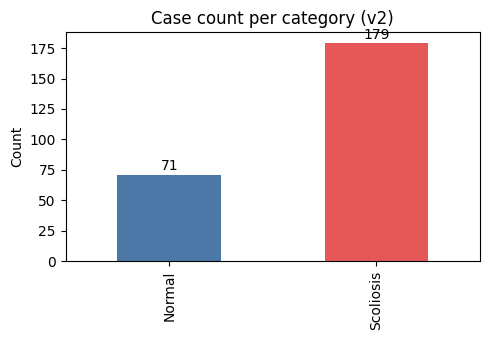

In [10]:
# ── 2.1 Category counts + class balance ratio ───────────────────────────────
cat_counts = INDEX["category"].value_counts().reindex(["Normal", "Scoliosis"]).fillna(0).astype(int)
print("Cases per category:")
print(cat_counts.to_string())
n_normal = int(cat_counts.get("Normal", 0))
n_scol   = int(cat_counts.get("Scoliosis", 0))
ratio = (n_scol / n_normal) if n_normal else float("inf")
print(f"\nClass balance ratio (Scoliosis : Normal) = {ratio:.2f} : 1")

fig, ax = plt.subplots(figsize=(5, 3.5))
cat_counts.plot(kind="bar", ax=ax, color=["#4c78a8", "#e45756"])
ax.set_title("Case count per category (v2)")
ax.set_ylabel("Count"); ax.set_xlabel("")
for i, v in enumerate(cat_counts.values):
    ax.text(i, v + 1, str(v), ha="center", va="bottom")
plt.tight_layout(); plt.show()


In [11]:
# ── 2.2 File inventory table per category ────────────────────────────────────
def _has_metrics_row(pid):
    try:
        return int(pid) in METRICS_BY_PID
    except (TypeError, ValueError):
        return False

inv_rows = []
for cat, sub in INDEX.groupby("category", observed=True):
    # metrics + curves + overlays only apply to Scoliosis
    metrics_rows = int(sub["patient_id"].dropna().map(_has_metrics_row).sum()) if cat == "Scoliosis" else 0
    inv_rows.append({
        "category":     cat,
        "images":       sub["image_abs"].notna().sum(),
        "binary_masks": sub["binary_mask_abs"].notna().sum(),
        "multi_masks":  sub["multi_mask_abs"].notna().sum(),
        "metrics_rows": metrics_rows,
        "curve_csvs":   sub["curve_csv_abs"].notna().sum(),
        "overlays":     sub["overlay_abs"].notna().sum(),
    })
file_inventory = pd.DataFrame(inv_rows).set_index("category")
print("File inventory per category:")
print(file_inventory.to_string())


File inventory per category:
           images  binary_masks  multi_masks  metrics_rows  curve_csvs  overlays
category                                                                        
Normal         71            71           71             0           0         0
Scoliosis     179           179          179           178         179       178


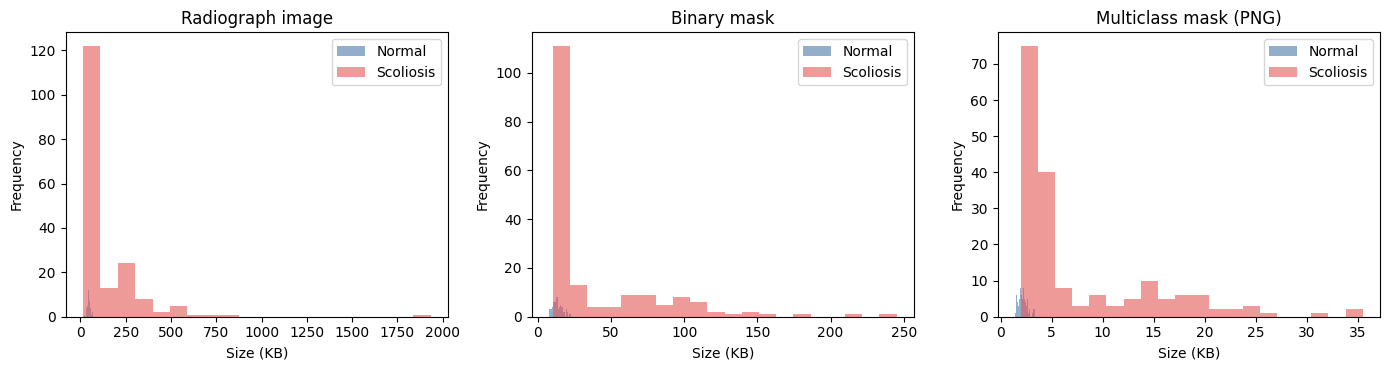

File size summary (KB):
  image        median=   46.4  min=   14.5  max=  1932.6
  binary_mask  median=   16.2  min=    7.7  max=   245.1
  multi_mask   median=    3.5  min=    1.4  max=    35.5


In [12]:
# ── 2.3 File size histograms (KB) per category ───────────────────────────────
sizes = pd.DataFrame({
    "category":    INDEX["category"],
    "image":       INDEX["image_abs"].map(file_size_kb),
    "binary_mask": INDEX["binary_mask_abs"].map(file_size_kb),
    "multi_mask":  INDEX["multi_mask_abs"].map(file_size_kb),
})

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, col, title in zip(
    axes,
    ["image", "binary_mask", "multi_mask"],
    ["Radiograph image", "Binary mask", "Multiclass mask (PNG)"],
):
    for cat, color in [("Normal", "#4c78a8"), ("Scoliosis", "#e45756")]:
        vals = sizes.loc[sizes["category"] == cat, col].dropna()
        if len(vals):
            ax.hist(vals, bins=20, alpha=0.6, label=cat, color=color)
    ax.set_title(title); ax.set_xlabel("Size (KB)"); ax.set_ylabel("Frequency"); ax.legend()
plt.tight_layout(); plt.show()

print("File size summary (KB):")
for col in ("image", "binary_mask", "multi_mask"):
    s = sizes[col].dropna()
    print(f"  {col:12s} median={s.median():7.1f}  min={s.min():7.1f}  max={s.max():8.1f}")


## 3. Image-Level Profile

In [13]:
# ── 3.1 Read image metadata (cheap — only header; guard against missing files) ──
_image_meta_rows = []
for _, r in INDEX.iterrows():
    if not r["image_abs"] or not Path(r["image_abs"]).exists():
        continue
    h, w, mode = read_image_meta(r["image_abs"])
    _image_meta_rows.append({
        "patient_id": r["patient_id"], "category": r["category"],
        "image": r["image"], "h": h, "w": w,
        "aspect": w / h if h else float("nan"), "mode": mode,
    })
IMAGE_META = pd.DataFrame(_image_meta_rows)
print(f"Loaded metadata for {len(IMAGE_META)} images.")
IMAGE_META.sample(3)


Loaded metadata for 249 images.


,patient_id,category,image,h,w,aspect,mode
137,88,Scoliosis,S_88.jpg,1021,474,0.464251,RGB
6,7,Normal,N_7.jpg,937,220,0.234792,RGB
97,47,Scoliosis,S_47.jpg,1008,432,0.428571,RGB


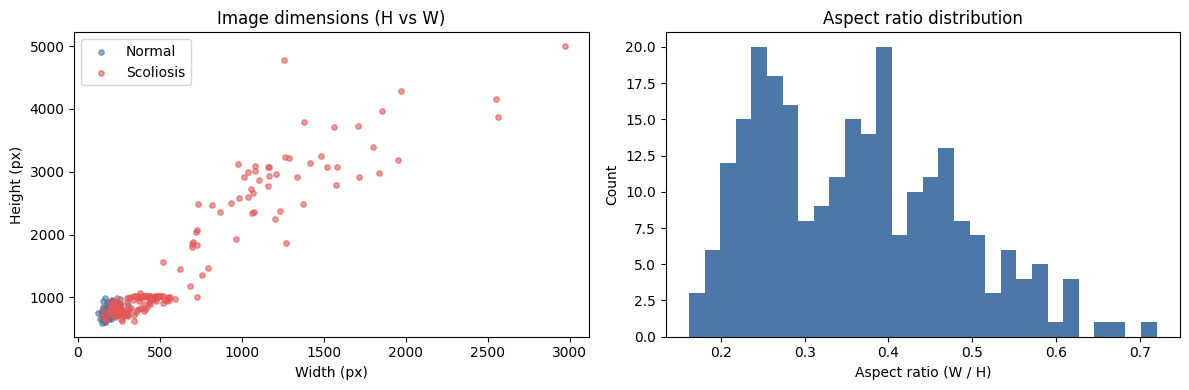

In [14]:
# ── 3.2 Dimensions scatter + aspect ratio histogram ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for cat, color in [("Normal", "#4c78a8"), ("Scoliosis", "#e45756")]:
    sub = IMAGE_META[IMAGE_META["category"] == cat]
    axes[0].scatter(sub["w"], sub["h"], alpha=0.6, label=cat, color=color, s=15)
axes[0].set_xlabel("Width (px)"); axes[0].set_ylabel("Height (px)")
axes[0].set_title("Image dimensions (H vs W)"); axes[0].legend()

axes[1].hist(IMAGE_META["aspect"], bins=30, color="#4c78a8")
axes[1].set_xlabel("Aspect ratio (W / H)"); axes[1].set_ylabel("Count")
axes[1].set_title("Aspect ratio distribution")
plt.tight_layout(); plt.show()


In [15]:
# ── 3.3 Resolution statistics ────────────────────────────────────────────────
print("Resolution stats (pixels):")
for col in ("h", "w"):
    vals = IMAGE_META[col]
    print(f"  {col}: median={int(vals.median())}  min={int(vals.min())}  max={int(vals.max())}")
print(f"\nMedian image: {int(IMAGE_META['h'].median())}x{int(IMAGE_META['w'].median())}")
print(f"Total pixels median: {int((IMAGE_META['h'] * IMAGE_META['w']).median()):,}")


Resolution stats (pixels):
  h: median=919  min=595  max=4999
  w: median=314  min=123  max=2972

Median image: 919x314
Total pixels median: 272,180


Channel mode counts (rows = category, columns = PIL mode):
mode       RGB
category      
Normal      71
Scoliosis  178


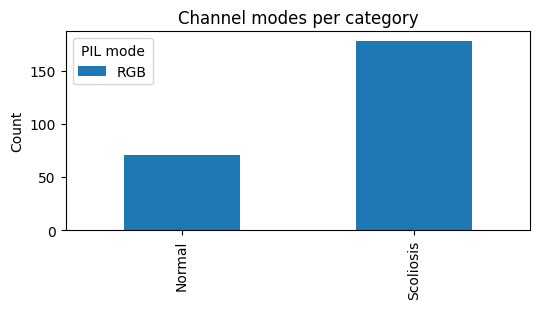

In [16]:
# ── 3.4 Channel mode count per category ──────────────────────────────────────
mode_counts = IMAGE_META.groupby(["category", "mode"], observed=True).size().unstack(fill_value=0)
print("Channel mode counts (rows = category, columns = PIL mode):")
print(mode_counts.to_string())

fig, ax = plt.subplots(figsize=(5.5, 3.2))
mode_counts.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
ax.set_title("Channel modes per category"); ax.set_ylabel("Count"); ax.set_xlabel("")
ax.legend(title="PIL mode")
plt.tight_layout(); plt.show()


## 4. Label-Level Profile

v2 label space is already collapsed: IDs `1..17` = T1..L5. No cervical (C3–C7) and no auxiliary entities, so the frequency plot is a simple 17-bar chart with no grey-bar legend.

In [17]:
# ── 4.1 Per-case presence sets and spine fraction (guard against missing files) ─
_label_rows = []
for _, r in INDEX.iterrows():
    if not r["multi_mask_abs"] or not Path(r["multi_mask_abs"]).exists():
        continue
    mm = read_multi_mask(r["multi_mask_abs"])
    present = all_ids_present(mm)
    target_present = present & set(TARGET_VERTEBRA_IDS)
    out_of_range = {i for i in present if i not in TARGET_VERTEBRA_IDS}
    bin_path = r["binary_mask_abs"]
    if bin_path and Path(bin_path).exists():
        bm = read_image(bin_path)
        if bm.ndim == 3:
            bm = bm[..., 0]
        spine_frac = float((bm > 127).mean())
    else:
        spine_frac = float("nan")
    _label_rows.append({
        "patient_id":          r["patient_id"],
        "category":            r["category"],
        "image":               r["image"],
        "all_ids_present":     sorted(present),
        "target_present_set":  sorted(target_present),
        "target_count":        len(target_present),
        "non_target_present":  sorted(out_of_range),
        "spine_pixel_frac":    spine_frac,
    })
LABEL_META = pd.DataFrame(_label_rows)
print(f"Scanned {len(LABEL_META)} multiclass masks.")
LABEL_META.head(2)


Scanned 249 multiclass masks.


,patient_id,category,image,all_ids_present,target_present_set,target_count,non_target_present,spine_pixel_frac
0,1,Normal,N_1.jpg,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",17,[],0.209409
1,2,Normal,N_2.jpg,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",17,[],0.196023


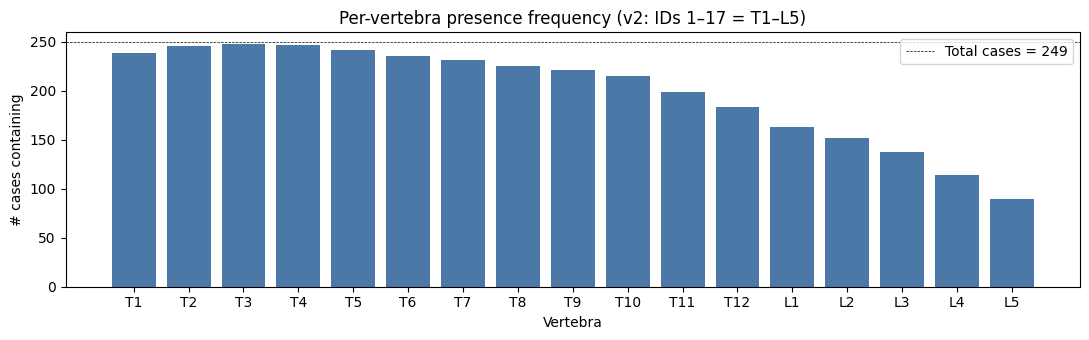

In [18]:
# ── 4.2 Per-vertebra presence frequency across IDs 1..17 ────────────────────
freq = {vid: 0 for vid in ALL_VERTEBRA_IDS}
for ids in LABEL_META["all_ids_present"]:
    for vid in ids:
        if vid in freq:
            freq[vid] += 1
freq_df = pd.DataFrame({
    "vertebra_id":   list(freq.keys()),
    "name":          [ALL_VERTEBRA_NAME_BY_ID[i] for i in freq.keys()],
    "present_count": list(freq.values()),
})

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.bar(freq_df["name"], freq_df["present_count"], color="#4c78a8")
ax.set_title("Per-vertebra presence frequency (v2: IDs 1–17 = T1–L5)")
ax.set_xlabel("Vertebra"); ax.set_ylabel("# cases containing")
ax.axhline(len(LABEL_META), color="black", lw=0.5, ls="--", label=f"Total cases = {len(LABEL_META)}")
ax.legend()
plt.tight_layout(); plt.show()


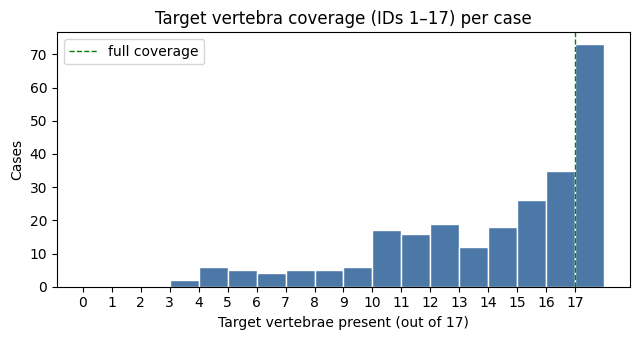

Coverage distribution:
target_count
3      2
4      6
5      5
6      4
7      5
8      5
9      6
10    17
11    16
12    19
13    12
14    18
15    26
16    35
17    73

Mean coverage: 13.58 / 17


In [19]:
# ── 4.3 Histogram of target vertebra coverage per case ──────────────────────
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(LABEL_META["target_count"], bins=range(0, TARGET_COVERAGE_FULL + 2),
        color="#4c78a8", edgecolor="white")
ax.set_xticks(range(0, TARGET_COVERAGE_FULL + 1))
ax.set_xlabel("Target vertebrae present (out of 17)"); ax.set_ylabel("Cases")
ax.set_title("Target vertebra coverage (IDs 1–17) per case")
ax.axvline(TARGET_COVERAGE_FULL, color="green", lw=1, ls="--", label="full coverage")
ax.legend()
plt.tight_layout(); plt.show()

print("Coverage distribution:")
print(LABEL_META["target_count"].value_counts().sort_index().to_string())
print(f"\nMean coverage: {LABEL_META['target_count'].mean():.2f} / {TARGET_COVERAGE_FULL}")


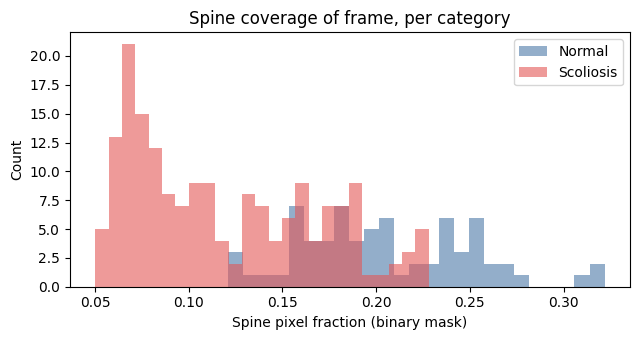

           count      mean       std       min       25%       50%       75%  \
category                                                                       
Normal      71.0  0.205307  0.045861  0.121170  0.170183  0.200099  0.239661   
Scoliosis  178.0  0.118251  0.049187  0.050235  0.073580  0.106361  0.159502   

                max  
category             
Normal     0.321836  
Scoliosis  0.228051  


In [20]:
# ── 4.4 Spine pixel fraction (binary mask) per category ─────────────────────
fig, ax = plt.subplots(figsize=(6.5, 3.5))
for cat, color in [("Normal", "#4c78a8"), ("Scoliosis", "#e45756")]:
    sub = LABEL_META[LABEL_META["category"] == cat]
    ax.hist(sub["spine_pixel_frac"].dropna(), bins=25, alpha=0.6, label=cat, color=color)
ax.set_xlabel("Spine pixel fraction (binary mask)"); ax.set_ylabel("Count")
ax.set_title("Spine coverage of frame, per category"); ax.legend()
plt.tight_layout(); plt.show()
print(LABEL_META.groupby("category", observed=True)["spine_pixel_frac"].describe())


## 5. Metrics-Level Profile

All scoliosis metrics live in `metricas_cobb_resumen_recalculado.csv`. Apex and inflection points are stored directly as pixel coordinates — no need to dereference curve indices as in v1.

CSVL is not available in v2, so that plot is dropped.

In [21]:
# ── 5.1 Build per-case metrics frame (Scoliosis only, from pooled CSV) ──────
_metrics_rows = []
for _, r in INDEX.iterrows():
    if r["category"] != "Scoliosis":
        continue
    pid = int(r["patient_id"]) if pd.notna(r["patient_id"]) else None
    mrow = METRICS_BY_PID.get(pid) if pid is not None else None
    if mrow is None:
        continue
    try:
        cobb = float(mrow["angulo_cobb_deg"])
    except (TypeError, ValueError, KeyError):
        cobb = None
    apex_x = mrow.get("punto_apice_x_px")
    apex_y = mrow.get("punto_apice_y_px")

    curve_len = None
    if r["curve_csv_abs"]:
        try:
            curve_len = len(read_curve_csv(r["curve_csv_abs"]))
        except Exception:
            curve_len = None

    _metrics_rows.append({
        "patient_id": pid,
        "image":      r["image"],
        "cobb_deg":   cobb,
        "apex_x":     float(apex_x) if pd.notna(apex_x) else None,
        "apex_y":     float(apex_y) if pd.notna(apex_y) else None,
        "curve_len":  curve_len,
    })
METRICS = pd.DataFrame(_metrics_rows)
print(f"Loaded metrics for {len(METRICS)} scoliosis cases.")
METRICS.head(3)


Loaded metrics for 178 scoliosis cases.


,patient_id,image,cobb_deg,apex_x,apex_y,curve_len
0,21,S_21.jpg,39.968698,118.264809,426.0,719
1,22,S_22.jpg,24.874765,116.781021,639.0,812
2,23,S_23.jpg,58.485295,211.312256,499.0,730


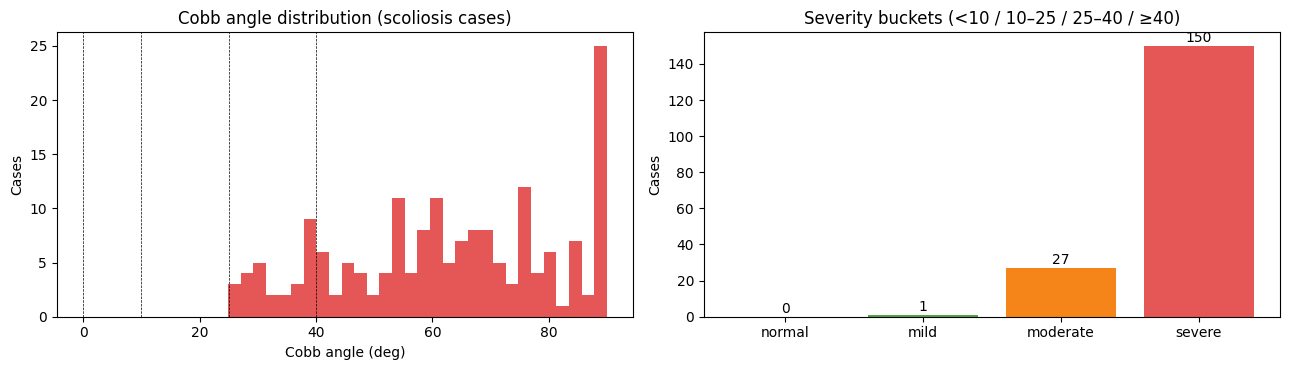

Severity counts:
severity
normal        0
mild          1
moderate     27
severe      150


In [22]:
# ── 5.2 Cobb angle histogram + severity bucket bar chart ────────────────────
def severity_for(angle) -> str:
    if angle is None or pd.isna(angle):
        return "unknown"
    for name, lo, hi in SEVERITY_BUCKETS:
        if lo <= angle < hi:
            return name
    return "severe"

METRICS["severity"] = METRICS["cobb_deg"].map(severity_for)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].hist(METRICS["cobb_deg"].dropna(), bins=30, color="#e45756")
for _, lo, _ in SEVERITY_BUCKETS:
    axes[0].axvline(lo, color="black", lw=0.5, ls="--")
axes[0].set_xlabel("Cobb angle (deg)"); axes[0].set_ylabel("Cases")
axes[0].set_title("Cobb angle distribution (scoliosis cases)")

severity_order = [name for name, _, _ in SEVERITY_BUCKETS]
sev_counts = METRICS["severity"].value_counts().reindex(severity_order, fill_value=0)
axes[1].bar(sev_counts.index, sev_counts.values, color=["#4c78a8", "#54a24b", "#f58518", "#e45756"])
axes[1].set_title("Severity buckets (<10 / 10–25 / 25–40 / ≥40)"); axes[1].set_ylabel("Cases")
for i, v in enumerate(sev_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha="center", va="bottom")
plt.tight_layout(); plt.show()

print("Severity counts:")
print(sev_counts.to_string())


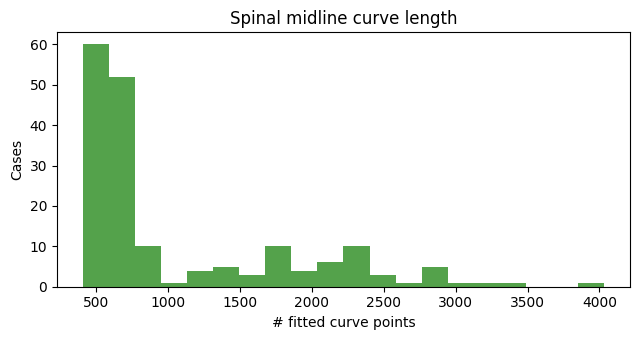

count     178.000000
mean     1082.067416
std       767.282567
min       411.000000
25%       573.750000
50%       676.000000
75%      1599.500000
max      4031.000000


In [23]:
# ── 5.3 Curve length distribution ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.hist(METRICS["curve_len"].dropna(), bins=20, color="#54a24b")
ax.set_xlabel("# fitted curve points"); ax.set_ylabel("Cases")
ax.set_title("Spinal midline curve length")
plt.tight_layout(); plt.show()
print(METRICS["curve_len"].describe().to_string())


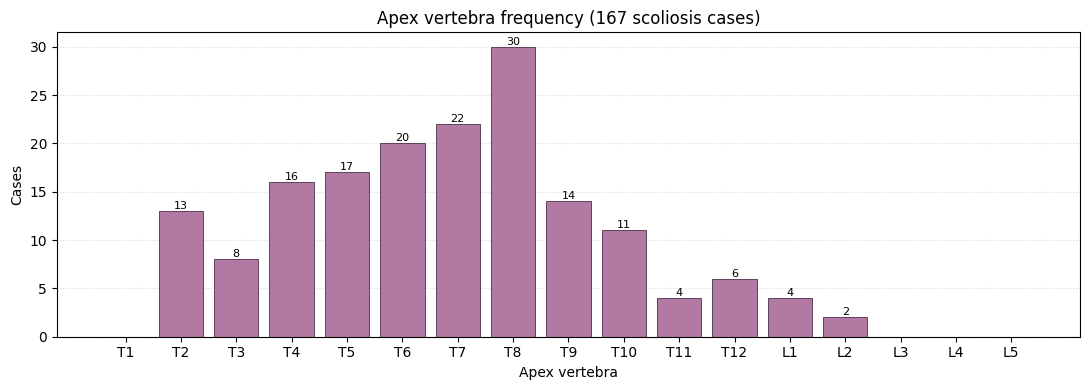

In [24]:
# ── 5.4 Apex vertebra frequency (v2: look up mask directly at apex px) ──────
apex_vid_counts: Counter = Counter()
multi_by_pid = {int(r["patient_id"]): r["multi_mask_abs"]
                for _, r in INDEX.iterrows()
                if r["category"] == "Scoliosis"
                and pd.notna(r["patient_id"])
                and r["multi_mask_abs"]}

for _, r in METRICS.iterrows():
    if pd.isna(r["apex_x"]) or pd.isna(r["apex_y"]):
        continue
    pid = int(r["patient_id"])
    mm_path = multi_by_pid.get(pid)
    if not mm_path:
        continue
    try:
        mm = read_multi_mask(mm_path)
        x = int(round(float(r["apex_x"])))
        y = int(round(float(r["apex_y"])))
        if not (0 <= y < mm.shape[0] and 0 <= x < mm.shape[1]):
            continue
        vid = int(mm[y, x])
        if vid in TARGET_VERTEBRA_IDS:
            apex_vid_counts[vid] += 1
    except Exception:
        continue

ordered_vids = list(TARGET_VERTEBRA_IDS)
counts = [apex_vid_counts.get(v, 0) for v in ordered_vids]
labels = [VERTEBRA_NAME_BY_ID[v] for v in ordered_vids]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(labels, counts, color="#b279a2", edgecolor="#4a2e4a", linewidth=0.6)
ax.set_xlabel("Apex vertebra"); ax.set_ylabel("Cases")
ax.set_title(f"Apex vertebra frequency ({sum(counts)} scoliosis cases)")
ax.grid(axis="y", linestyle=":", alpha=0.5); ax.set_axisbelow(True)
for i_bar, c in enumerate(counts):
    if c > 0:
        ax.text(i_bar, c, str(c), ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()


## 6. Cross-Cut Sanity Correlations

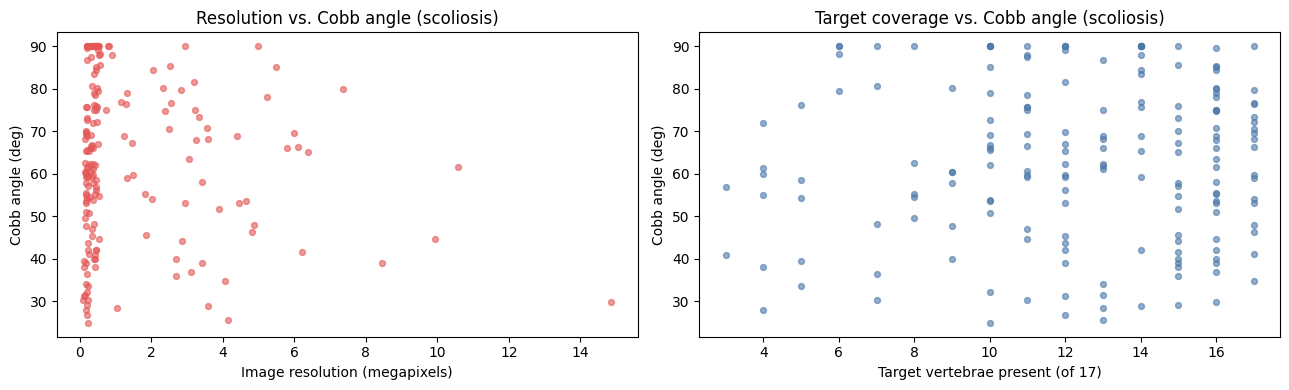

In [25]:
_join_meta = (
    METRICS
    .merge(IMAGE_META[["image", "h", "w"]], on="image", how="left")
    .merge(LABEL_META[["image", "target_count"]], on="image", how="left")
)
_join_meta["mp"] = _join_meta["h"] * _join_meta["w"] / 1e6

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter(_join_meta["mp"], _join_meta["cobb_deg"], alpha=0.6, color="#e45756", s=18)
axes[0].set_xlabel("Image resolution (megapixels)"); axes[0].set_ylabel("Cobb angle (deg)")
axes[0].set_title("Resolution vs. Cobb angle (scoliosis)")

axes[1].scatter(_join_meta["target_count"], _join_meta["cobb_deg"], alpha=0.6, color="#4c78a8", s=18)
axes[1].set_xlabel("Target vertebrae present (of 17)"); axes[1].set_ylabel("Cobb angle (deg)")
axes[1].set_title("Target coverage vs. Cobb angle (scoliosis)")
plt.tight_layout(); plt.show()


## 7. Inconsistency Audit

Detectors match v1 except:

- `csvl_apex_out_of_range` is **dropped** (no CSVL in v2).
- `id_out_of_range` rarely fires because v2 mask space is already 0–17.
- Scoliosis cases without a row in `metricas_cobb_resumen_recalculado.csv` trigger `missing_pair_metrics` + `missing_metadata_scoliosis`.

In [26]:
def _issue(patient_id, category, code: str, severity: str, details: str = "") -> dict:
    return {
        "patient_id": int(patient_id) if patient_id is not None and not pd.isna(patient_id) else None,
        "category":   category,
        "issue_code": code,
        "severity":   severity,
        "details":    details,
    }

DETECTORS: list[tuple[str, Callable[[], list[dict]]]] = []


In [27]:
# ── 7.1 Structural integrity detectors ──────────────────────────────────────
def detect_structural() -> list[dict]:
    out: list[dict] = []
    seen_pid: dict[tuple[str, int], int] = {}
    for i, r in INDEX.iterrows():
        pid = r["patient_id"]; cat = r["category"]; img = r["image"]

        if not r["binary_mask_abs"] or not Path(r["binary_mask_abs"]).exists():
            out.append(_issue(pid, cat, "missing_pair_binary_mask", "fatal", f"image={img}"))
        if not r["multi_mask_abs"] or not Path(r["multi_mask_abs"]).exists():
            out.append(_issue(pid, cat, "missing_pair_multi_mask", "fatal", f"image={img}"))
        if cat == "Scoliosis":
            pid_int = int(pid) if pd.notna(pid) else None
            if pid_int is None or pid_int not in METRICS_BY_PID:
                out.append(_issue(pid, cat, "missing_pair_metrics", "warn",
                                  f"image={img} (no row in metricas_cobb_resumen_recalculado.csv)"))
            if not r["curve_csv_abs"] or not Path(r["curve_csv_abs"]).exists():
                out.append(_issue(pid, cat, "missing_pair_curve", "warn", f"image={img}"))

        try:
            if r["image_abs"]:
                read_image_meta(r["image_abs"])
        except Exception as e:
            out.append(_issue(pid, cat, "corrupt_file", "fatal", f"image: {e}"))

        stem = Path(img).stem if isinstance(img, str) else ""
        prefix = stem.split("_", 1)[0] if "_" in stem else ""
        expected = "S" if cat == "Scoliosis" else "N" if cat == "Normal" else None
        if expected and prefix != expected:
            out.append(_issue(pid, cat, "index_mismatch", "fatal",
                              f"image stem prefix '{prefix}' != expected '{expected}'"))

        key = (cat, int(pid)) if pd.notna(pid) else None
        if key is not None:
            if key in seen_pid:
                out.append(_issue(pid, cat, "duplicate_patient_id", "fatal",
                                  f"first seen at index {seen_pid[key]}"))
            else:
                seen_pid[key] = i
    return out

DETECTORS.append(("structural", detect_structural))
print(f"Registered structural detector ({len(DETECTORS)} total)")


Registered structural detector (1 total)


In [28]:
# ── 7.2 Spatial detectors ────────────────────────────────────────────────────
def detect_spatial() -> list[dict]:
    out: list[dict] = []
    hs = IMAGE_META["h"].astype(float); ws = IMAGE_META["w"].astype(float)
    h_med, h_std = hs.median(), hs.std()
    w_med, w_std = ws.median(), ws.std()
    img_meta_by_image = {row["image"]: row for _, row in IMAGE_META.iterrows()}

    for _, r in INDEX.iterrows():
        pid = r["patient_id"]; cat = r["category"]; img = r["image"]
        meta = img_meta_by_image.get(img)
        if meta is None:
            continue
        ih, iw, imode = int(meta["h"]), int(meta["w"]), meta["mode"]

        for label_path, label_name in [
            (r["binary_mask_abs"], "binary_mask"),
            (r["multi_mask_abs"], "multi_mask"),
        ]:
            if not label_path or not Path(label_path).exists():
                continue
            try:
                lh, lw, _ = read_image_meta(label_path)
            except Exception:
                continue
            if (lh, lw) != (ih, iw):
                out.append(_issue(pid, cat, "dim_mismatch", "fatal",
                                  f"{label_name}={lh}x{lw} vs image={ih}x{iw}"))

        if abs(ih - h_med) > 2 * h_std or abs(iw - w_med) > 2 * w_std:
            out.append(_issue(pid, cat, "resolution_outlier", "warn",
                              f"image={ih}x{iw}, median={int(h_med)}x{int(w_med)} std=({h_std:.0f},{w_std:.0f})"))

        if imode not in DOMINANT_IMAGE_MODES:
            out.append(_issue(pid, cat, "channel_inconsistency", "warn",
                              f"mode={imode}, expected one of {sorted(DOMINANT_IMAGE_MODES)}"))
    return out

_mode_pct = IMAGE_META["mode"].value_counts(normalize=True)
DOMINANT_IMAGE_MODES = set(_mode_pct[_mode_pct >= 0.05].index.tolist()) or set(_mode_pct.index[:1])
print(f"Dominant image modes (≥5% of cases): {sorted(DOMINANT_IMAGE_MODES)}")

DETECTORS.append(("spatial", detect_spatial))
print(f"Registered spatial detector ({len(DETECTORS)} total)")


Dominant image modes (≥5% of cases): ['RGB']
Registered spatial detector (2 total)


In [29]:
# ── 7.3 Label-content detectors ──────────────────────────────────────────────
def detect_label_content() -> list[dict]:
    out: list[dict] = []
    label_by_image = {row["image"]: row for _, row in LABEL_META.iterrows()}
    for _, r in INDEX.iterrows():
        pid = r["patient_id"]; cat = r["category"]; img = r["image"]
        lm = label_by_image.get(img)
        if lm is None:
            continue
        target_count = int(lm["target_count"])
        non_target = set(lm["non_target_present"])

        if non_target:
            out.append(_issue(pid, cat, "id_out_of_range", "info",
                              f"non_target_ids={sorted(non_target)}"))
        if target_count < 14:
            out.append(_issue(pid, cat, "target_coverage_low", "warn",
                              f"target_count={target_count} (<14)"))
        if target_count == 0:
            out.append(_issue(pid, cat, "empty_mask", "fatal", "no target vertebrae present"))
    return out

DETECTORS.append(("label_content", detect_label_content))
print(f"Registered label-content detector ({len(DETECTORS)} total)")


Registered label-content detector (3 total)


In [30]:
# ── 7.4 Metrics & curve detectors (no CSVL in v2) ────────────────────────────
def detect_metrics_curve() -> list[dict]:
    out: list[dict] = []
    for _, r in INDEX.iterrows():
        pid = r["patient_id"]; cat = r["category"]; img = r["image"]
        if cat != "Scoliosis":
            continue
        pid_int = int(pid) if pd.notna(pid) else None
        mrow = METRICS_BY_PID.get(pid_int) if pid_int is not None else None
        if mrow is None:
            out.append(_issue(pid, cat, "missing_metadata_scoliosis", "warn",
                              "no row in metricas_cobb_resumen_recalculado.csv"))
            continue

        cobb = mrow.get("angulo_cobb_deg")
        try:
            cobb_f = float(cobb) if cobb is not None and pd.notna(cobb) else None
        except (TypeError, ValueError):
            cobb_f = None
        if cobb_f is None:
            out.append(_issue(pid, cat, "missing_metadata_scoliosis", "warn",
                              "metrics missing angulo_cobb_deg"))
        else:
            if cobb_f < 5.0 or cobb_f > 120.0:
                out.append(_issue(pid, cat, "cobb_angle_outlier", "warn", f"cobb={cobb_f:.1f}"))
            if cobb_f == 0.0:
                out.append(_issue(pid, cat, "category_mislabeled", "fatal",
                                  "scoliosis case with angulo_cobb_deg == 0"))

        cv = r["curve_csv_abs"]
        if cv and Path(cv).exists():
            try:
                curve_df = read_curve_csv(cv)
                if len(curve_df) < 5:
                    out.append(_issue(pid, cat, "curve_invalid", "warn",
                                      f"curve has only {len(curve_df)} points"))
                else:
                    cols_lower = {c.lower() for c in curve_df.columns}
                    if "x_px" not in cols_lower and "x" not in cols_lower:
                        out.append(_issue(pid, cat, "curve_invalid", "warn",
                                          f"curve missing x column: {list(curve_df.columns)}"))
            except Exception as e:
                out.append(_issue(pid, cat, "curve_invalid", "warn", f"unparsable curve: {e}"))
    return out

DETECTORS.append(("metrics_curve", detect_metrics_curve))
print(f"Registered metrics/curve detector ({len(DETECTORS)} total)")


Registered metrics/curve detector (4 total)


## 8. Aggregate Detectors → `known_issues.csv`

In [31]:
def run_detectors() -> pd.DataFrame:
    random.seed(SEED); np.random.seed(SEED)
    rows: list[dict] = []
    for name, fn in DETECTORS:
        out = fn()
        print(f"  detector {name:14s} → {len(out):4d} issues")
        rows.extend(out)
    return pd.DataFrame(
        rows, columns=["patient_id", "category", "issue_code", "severity", "details"],
    ).sort_values(
        ["patient_id", "category", "issue_code", "severity", "details"],
        kind="mergesort",
    ).reset_index(drop=True)

ISSUES = run_detectors()
print(f"\nTotal issue rows: {len(ISSUES)}")


  detector structural     →    4 issues
  detector spatial        →   33 issues
  detector label_content  →   97 issues
  detector metrics_curve  →    1 issues

Total issue rows: 135


In [32]:
ISSUES.to_csv(KNOWN_ISSUES_CSV, index=False, lineterminator="\n")
print(f"Wrote {KNOWN_ISSUES_CSV}  ({len(ISSUES)} rows)")


Wrote /home/ortiz/scoliosis/data/processed/audit_v2/known_issues.csv  (135 rows)


In [33]:
summary = (
    ISSUES.groupby(["issue_code", "severity"], observed=True)
          .size()
          .unstack(fill_value=0)
          .reindex(list(EXPECTED_ISSUE_CODES), fill_value=0)
)
for col in ("info", "warn", "fatal"):
    if col not in summary.columns:
        summary[col] = 0
summary = summary[["info", "warn", "fatal"]]
print("Issue-code summary (rows = code, columns = severity):")
print(summary.to_string())


Issue-code summary (rows = code, columns = severity):
severity                    info  warn  fatal
issue_code                                   
missing_pair_binary_mask       0     0      1
missing_pair_multi_mask        0     0      1
missing_pair_metrics           0     1      0
missing_pair_curve             0     0      0
corrupt_file                   0     0      1
index_mismatch                 0     0      0
category_mislabeled            0     0      0
duplicate_patient_id           0     0      0
dim_mismatch                   0     0      0
resolution_outlier             0    33      0
channel_inconsistency          0     0      0
id_out_of_range                0     0      0
target_coverage_low            0    97      0
empty_mask                     0     0      0
cobb_angle_outlier             0     0      0
missing_metadata_scoliosis     0     1      0
curve_invalid                  0     0      0


## 9. Clean Manifest `clean_index.csv`

In [34]:
def build_clean_index(issues: pd.DataFrame) -> pd.DataFrame:
    label_by_image   = {r["image"]: r for _, r in LABEL_META.iterrows()}
    meta_by_image    = {r["image"]: r for _, r in IMAGE_META.iterrows()}
    metrics_by_image = {r["image"]: r for _, r in METRICS.iterrows()} if len(METRICS) else {}

    codes_by_key: dict[tuple[int, str], list[str]] = {}
    for _, ir in issues.iterrows():
        if ir["patient_id"] is None or pd.isna(ir["patient_id"]):
            continue
        key = (int(ir["patient_id"]), ir["category"])
        codes_by_key.setdefault(key, []).append(ir["issue_code"])

    def classify(target_count: int, codes: list[str]) -> str:
        code_set = set(codes)
        if code_set & EXCLUDE_TRIGGER_CODES or target_count <= 13:
            return "excluded"
        if target_count in (14, 15, 16) or code_set & WARN_TRIGGER_CODES:
            return "warn"
        if target_count == 17:
            return "ok"
        return "warn"

    rows = []
    for _, r in INDEX.iterrows():
        img = r["image"]
        pid = int(r["patient_id"]) if pd.notna(r["patient_id"]) else None
        cat = r["category"]
        meta = meta_by_image.get(img)
        lab  = label_by_image.get(img)
        mtr  = metrics_by_image.get(img)
        target_present = sorted(lab["target_present_set"]) if lab is not None else []
        target_count = len(target_present)
        target_names = ",".join(VERTEBRA_NAME_BY_ID[v] for v in target_present)
        codes = codes_by_key.get((pid, cat), []) if pid is not None else []
        rows.append({
            "patient_id":               pid,
            "category":                 cat,
            "image_path":               r["image_abs"],
            "binary_mask_path":         r["binary_mask_abs"],
            "multiclass_mask_path":     r["multi_mask_abs"],
            "curve_csv_path":           r["curve_csv_abs"],
            "overlay_path":             r["overlay_abs"],
            "image_h":                  int(meta["h"]) if meta is not None else None,
            "image_w":                  int(meta["w"]) if meta is not None else None,
            "cobb_angle_deg":           float(mtr["cobb_deg"]) if (mtr is not None and pd.notna(mtr.get("cobb_deg"))) else None,
            "target_vertebrae_count":   target_count,
            "target_vertebrae_present": target_names,
            "status":                   classify(target_count, codes),
            "issues":                   ";".join(sorted(set(codes))),
        })
    return pd.DataFrame(
        rows,
        columns=[
            "patient_id", "category", "image_path", "binary_mask_path", "multiclass_mask_path",
            "curve_csv_path", "overlay_path", "image_h", "image_w", "cobb_angle_deg",
            "target_vertebrae_count", "target_vertebrae_present", "status", "issues",
        ],
    ).sort_values(["category", "patient_id"], kind="mergesort").reset_index(drop=True)

CLEAN_INDEX = build_clean_index(ISSUES)
assert len(CLEAN_INDEX) == len(INDEX), "row count must equal raw dataset_index.csv"
print(f"Built clean index: {len(CLEAN_INDEX)} rows (raw index = {len(INDEX)})")
CLEAN_INDEX.head(3)


Built clean index: 250 rows (raw index = 250)


,patient_id,category,image_path,binary_mask_path,multiclass_mask_path,curve_csv_path,overlay_path,image_h,image_w,cobb_angle_deg,target_vertebrae_count,target_vertebrae_present,status,issues
0,1,Normal,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,None,None,971.0,259.0,NaN,17,"T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,L1,L2,L...",ok,
1,2,Normal,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,None,None,828.0,218.0,NaN,17,"T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,L1,L2,L...",ok,
2,3,Normal,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,/home/ortiz/scoliosis/data/raw/Scoliosis_Datas...,None,None,939.0,206.0,NaN,17,"T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,T11,T12,L1,L2,L...",ok,


In [35]:
CLEAN_INDEX.to_csv(CLEAN_INDEX_CSV, index=False, lineterminator="\n")
print(f"Wrote {CLEAN_INDEX_CSV}  ({len(CLEAN_INDEX)} rows)")


Wrote /home/ortiz/scoliosis/data/processed/audit_v2/clean_index.csv  (250 rows)


In [36]:
status_counts = CLEAN_INDEX["status"].value_counts().reindex(["ok", "warn", "excluded"], fill_value=0)
print("Cases per status:")
print(status_counts.to_string())
print(f"\nTotal: {int(status_counts.sum())} (must equal raw index = {len(INDEX)})")


Cases per status:
status
ok          65
warn        87
excluded    98

Total: 250 (must equal raw index = 250)


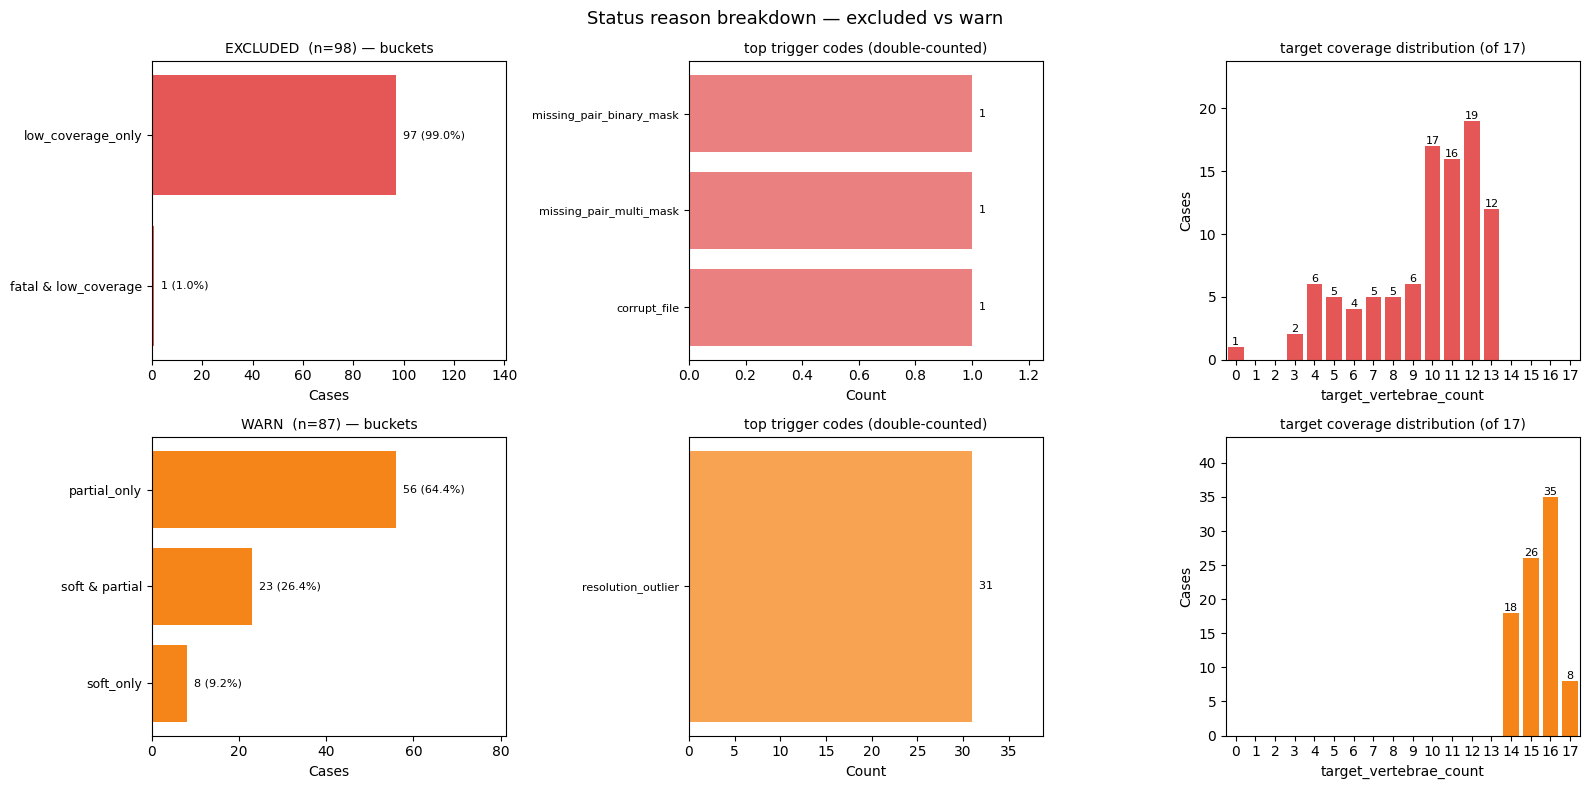

In [37]:
# ── Status reason breakdown (graphical) ─────────────────────────────────────
def _row_codes(row) -> set[str]:
    return {c for c in str(row["issues"]).split(";") if c}

def _bucket(status: str, codes: set[str], tc: int) -> str:
    if status == "excluded":
        has_fatal = bool(codes & EXCLUDE_TRIGGER_CODES)
        low_cov = tc <= 13
        if has_fatal and low_cov: return "fatal & low_coverage"
        if has_fatal: return "fatal_only"
        if low_cov: return "low_coverage_only"
        raise AssertionError(f"excluded row with no reason: codes={codes}, tc={tc}")
    if status == "warn":
        has_soft = bool(codes & WARN_TRIGGER_CODES)
        partial = tc in (14, 15, 16)
        if has_soft and partial: return "soft & partial"
        if has_soft: return "soft_only"
        if partial: return "partial_only"
        raise AssertionError(f"warn row with no reason: codes={codes}, tc={tc}")
    return "n/a"

def _aggregate(status: str, trigger_codes: frozenset[str]):
    sub = CLEAN_INDEX[CLEAN_INDEX["status"] == status]
    buckets: Counter[str] = Counter()
    code_counter: Counter[str] = Counter()
    for _, r in sub.iterrows():
        codes = _row_codes(r)
        tc = int(r["target_vertebrae_count"])
        buckets[_bucket(status, codes, tc)] += 1
        for c in codes & trigger_codes:
            code_counter[c] += 1
    cov = sub["target_vertebrae_count"].value_counts().sort_index()
    return len(sub), buckets, code_counter, cov

def _empty(ax, msg="(none)"):
    ax.text(0.5, 0.5, msg, ha="center", va="center", transform=ax.transAxes, color="#999", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

def _plot_row(axes, status, trigger_codes, color):
    n, buckets, code_counter, cov = _aggregate(status, trigger_codes)
    ax_b, ax_c, ax_cov = axes
    tag = f"{status.upper()}  (n={n})"

    if buckets:
        items = buckets.most_common()
        names = [k for k, _ in items]; vals = [v for _, v in items]
        ypos = list(range(len(names)))[::-1]
        ax_b.barh(ypos, vals, color=color); ax_b.set_yticks(ypos)
        ax_b.set_yticklabels(names, fontsize=9)
        for y, v in zip(ypos, vals):
            ax_b.text(v, y, f"  {v} ({100.0*v/n:.1f}%)", va="center", fontsize=8)
        ax_b.set_xlim(0, max(vals) * 1.45)
    else:
        _empty(ax_b)
    ax_b.set_title(f"{tag} — buckets", fontsize=10); ax_b.set_xlabel("Cases")

    if code_counter:
        items = code_counter.most_common()
        names = [k for k, _ in items]; vals = [v for _, v in items]
        ypos = list(range(len(names)))[::-1]
        ax_c.barh(ypos, vals, color=color, alpha=0.75); ax_c.set_yticks(ypos)
        ax_c.set_yticklabels(names, fontsize=8)
        for y, v in zip(ypos, vals):
            ax_c.text(v, y, f"  {v}", va="center", fontsize=8)
        ax_c.set_xlim(0, max(vals) * 1.25)
    else:
        _empty(ax_c, "(no trigger codes)")
    ax_c.set_title("top trigger codes (double-counted)", fontsize=10); ax_c.set_xlabel("Count")

    if len(cov):
        xs = cov.index.astype(int).to_numpy(); ys = cov.values
        ax_cov.bar(xs, ys, color=color)
        for x, v in zip(xs, ys):
            ax_cov.text(x, v, str(int(v)), ha="center", va="bottom", fontsize=8)
        ax_cov.set_ylim(0, max(ys) * 1.25)
        ax_cov.set_xticks(list(range(0, 18))); ax_cov.set_xlim(-0.5, 17.5)
    else:
        _empty(ax_cov)
    ax_cov.set_title("target coverage distribution (of 17)", fontsize=10)
    ax_cov.set_xlabel("target_vertebrae_count"); ax_cov.set_ylabel("Cases")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
_plot_row(axes[0], "excluded", EXCLUDE_TRIGGER_CODES, "#e45756")
_plot_row(axes[1], "warn",     WARN_TRIGGER_CODES,    "#f58518")
fig.suptitle("Status reason breakdown — excluded vs warn", fontsize=13)
plt.tight_layout(); plt.show()


## 10. Reproducibility Verification

In [38]:
def _df_hash(df: pd.DataFrame) -> str:
    return hashlib.sha256(df.to_csv(index=False, lineterminator="\n").encode()).hexdigest()

ISSUES2 = run_detectors()
CLEAN2  = build_clean_index(ISSUES2)

h1_issues, h2_issues = _df_hash(ISSUES), _df_hash(ISSUES2)
h1_clean,  h2_clean  = _df_hash(CLEAN_INDEX), _df_hash(CLEAN2)

print(f"known_issues  first={h1_issues}")
print(f"              repro={h2_issues}")
print(f"clean_index   first={h1_clean}")
print(f"              repro={h2_clean}")

assert h1_issues == h2_issues, "known_issues.csv NOT byte-identical across reruns"
assert h1_clean  == h2_clean,  "clean_index.csv  NOT byte-identical across reruns"
print("\n✓ Reproducibility verified: in-kernel rerun produces byte-identical outputs.")


  detector structural     →    4 issues
  detector spatial        →   33 issues
  detector label_content  →   97 issues
  detector metrics_curve  →    1 issues
known_issues  first=9d846be18b3b0f53ab1f1f75d51279f54a9c48df2b7051b7e89e77f21f09006f
              repro=9d846be18b3b0f53ab1f1f75d51279f54a9c48df2b7051b7e89e77f21f09006f
clean_index   first=8bacb13792aacc196d6d7b50b48fc8b8f1ef1863e1bcbf717404732cdb476ddb
              repro=8bacb13792aacc196d6d7b50b48fc8b8f1ef1863e1bcbf717404732cdb476ddb

✓ Reproducibility verified: in-kernel rerun produces byte-identical outputs.


In [39]:
print("=" * 60)
print("Dataset v2 Audit Complete")
print("=" * 60)
print(f"Raw index rows:         {len(INDEX)}")
print(f"Issue rows:             {len(ISSUES)}")
print(f"Status counts:          {dict(status_counts)}")
print("Outputs:")
print(f"  {KNOWN_ISSUES_CSV.relative_to(REPO_ROOT)}")
print(f"  {CLEAN_INDEX_CSV.relative_to(REPO_ROOT)}")
print(f"Seed:                   {SEED}")


Dataset v2 Audit Complete
Raw index rows:         250
Issue rows:             135
Status counts:          {'ok': np.int64(65), 'warn': np.int64(87), 'excluded': np.int64(98)}
Outputs:
  data/processed/audit_v2/known_issues.csv
  data/processed/audit_v2/clean_index.csv
Seed:                   42
